In [261]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy import stats
from scipy.stats import ttest_rel

import scienceplots

In [262]:
DARK_BLUE  = (0.0, 0.4667, 0.7333)
LIGHT_BLUE = (0.2, 0.7333, 0.9333)
GREEN      = (0.0, 0.6, 0.5333)
ORANGE     = (0.9333, 0.4667, 0.2)
RED        = (0.8, 0.2, 0.0667)
PINK       = (0.9333, 0.2, 0.4667)
GRAY       = (0.7333, 0.7333, 0.7333)

SAVE = True

In [263]:
RUNS = {
    "FB": 
    {
        "folder": '/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/FB/02_23_22_49_LR_1_PW_04_HigherDeltaBCM_30_17_15_4',
        "color": ORANGE
    },
    "NFB": 
    {
        "folder": '/Users/juliuswuerzler/Desktop/Results_Thesis/NoFb',
        "color": DARK_BLUE
    },
    "x Reward": 
    {
        "folder": '/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/FB_Ablations/02_24_00_23_LR_1_PW_04_NoS_HigherDeltaBCM',
        "color":  "#C01050"
    },
    "x Punishment": 
    {
        "folder": '/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/FB_Ablations/02_24_00_23_LR_1_PW_04_NoR_HigherDeltaBCM',
        "color": PINK
    },
    "x Reset": 
    {
        "folder": '/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/FB_Ablations/02_24_00_23_LR_1_PW_04_NoReset_HigherDeltaBCM',
        "color": "#F68BB2"
    },
    # "R-P-Switch": 
    # {
    #     "folder": '/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/FB_Ablations/02_25_01_14_LR_1_PW_04__HigherDeltaBCM_SwitchHitMiss',
    #     "color": LIGHT_BLUE
    # },
    # "Silent": 
    # {
    #     "folder": '/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/FB_Ablations/02_25_01_14_LR_1_PW_04__HigherDeltaBCM_SilentFB',
    #     "color": LIGHT_BLUE
    # },
}

In [264]:
def ema(x, alpha=0.1):
    y = np.zeros_like(x, dtype=float)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i-1]
    return y


In [265]:
# Configuration
ALPHA = 0.05
N = 50

# Process each run
for run in RUNS:
    result_files = glob.glob(os.path.join(RUNS[run]['folder'], "*results.csv"))
    RUNS[run]['results'] = {}
    
    # Initialize collectors
    rolling_means = []
    start_end_collectors = {'start': [], 'end': []}
    
    # Process each network file
    for f in result_files:
        network = f.split('_')[-2]
        results = np.loadtxt(f)
        RUNS[run]['results'][network] = {}
        
        # Rolling mean
        smoothed_results = ema(results, ALPHA)
        RUNS[run]['results'][network]['rolling means'] = smoothed_results
        rolling_means.append(smoothed_results)
        
        # Start and end performance
        start_results = np.mean(results[:N])
        end_results = np.mean(results[-N:])
        RUNS[run]['results'][network]['s'] = start_results
        RUNS[run]['results'][network]['e'] = end_results
        start_end_collectors['start'].append(start_results)
        start_end_collectors['end'].append(end_results)
        
    # Store aggregated results
    RUNS[run]['rolling means'] = np.array(rolling_means)
    RUNS[run]['start'] = np.array(start_end_collectors['start'])
    RUNS[run]['end'] = np.array(start_end_collectors['end'])


In [266]:
# plt.style.use(['nature_d'])

# fig, ax = plt.subplots()

# # Plot configuration
# BOXPLOT_CONFIG = {
#     'widths': 0.5,
#     'patch_artist': True,
#     'showfliers': False,
#     'showmeans': True,
#     'meanprops': {
#         "markerfacecolor": 'black',
#         "markeredgecolor": 'black',
#         "markersize": 3
#     }
# }
# ax.axhline(40/95 * 100, linestyle='--', color='black', linewidth=1)
# ax.axhline(RUNS["FB"]['end'].mean()* 100, linestyle='--', color=ORANGE)

# fb_ablation_runs = ["N-S", "N-R", "N-PR", "R-P-Switch", "Silent"]

# for i, run in enumerate(fb_ablation_runs):
    
#     # if run == "FB" or run == "NFB":
#     #     ax.axhline(RUNS[run]['end'].mean() * 100,
#     #                color=RUNS[run]['color'],
#     #                label=run,
#     #                linestyle='--')
#     #     continue
#     print(f"{run}: {RUNS[run]['end'].mean():.3f}")
        
#     # Helper function to style boxplot
#     def style_boxplot(box_parts, color):
#         for box in box_parts['boxes']:
#             box.set_facecolor(color)
#             box.set_edgecolor('black')
#         for element in ['whiskers', 'caps', 'medians']:
#             for item in box_parts[element]:
#                 item.set_color('black')
#                 item.set_linewidth(1)

#     box_parts = ax.boxplot(
#             RUNS[run]['end'] * 100,
#             positions=[i],
#             **BOXPLOT_CONFIG
#         )
#     style_boxplot(box_parts, RUNS[run]['color'])
    
# ax.set_xticklabels(fb_ablation_runs)    

# ax.set_ylabel('Hit rate [%]')
# ax.set_xlabel('Condition')
# # ax.set_ylim([38, 60])

# # ax.legend()
# plt.show()
    

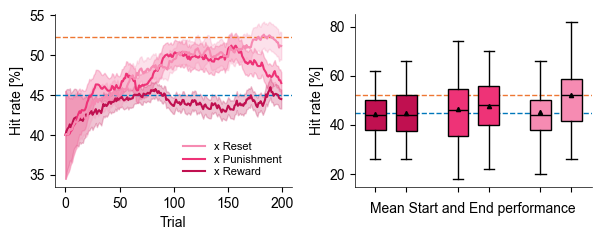

In [267]:
plt.style.use(['nature_d'])
fig, axs = plt.subplot_mosaic(
    [
        ["OT", "SvE"]
    ],
    sharey=False
)

BOXPLOT_CONFIG = {
    'widths': 0.5,
    'patch_artist': True,
    'showfliers': False,
    'showmeans': True,
    'meanprops': {
        "markerfacecolor": 'black',
        "markeredgecolor": 'black',
        "markersize": 3
    }
}

# axs['OT'].axhline(40/95 * 100, linestyle='--', color='black', linewidth=1)#, label='Chance')
# axs['SvE'].axhline(40/95 * 100, linestyle='--', color='black', linewidth=1)#, label='Chance')

for i, run in enumerate(RUNS):
    
    if run == "FB":
        axs['SvE'].axhline(RUNS[run]['end'].mean() * 100, linestyle='--' , color=ORANGE, linewidth=1)
        axs['OT'].axhline(RUNS[run]['end'].mean() * 100, linestyle='--' , color=ORANGE, linewidth=1)
        continue
    if run == "NFB":
        axs['SvE'].axhline(RUNS[run]['end'].mean() * 100, linestyle='--' , color=DARK_BLUE, linewidth=1)
        axs['OT'].axhline(RUNS[run]['end'].mean() * 100, linestyle='--' , color=DARK_BLUE, linewidth=1)
        continue
    
    data = RUNS[run]['rolling means']* 100
    color = RUNS[run]['color']
    
    # Plot rolling mean with SEM
    _mean = data.mean(axis=0) 
    sem = data.std(axis=0, ddof=1) / np.sqrt(data.shape[0])
    x = np.arange(len(_mean))
    
    axs["OT"].plot(x, _mean, color=color, alpha=1.0, linewidth=1.5, 
                   label=f'{run}') # (n={len(data)})
    axs["OT"].fill_between(x, _mean - sem, _mean + sem, color=color, alpha=0.25)
    
    # Helper function to style boxplot
    def style_boxplot(box_parts, color):
        for box in box_parts['boxes']:
            box.set_facecolor(color)
            box.set_edgecolor('black')
        for element in ['whiskers', 'caps', 'medians']:
            for item in box_parts[element]:
                item.set_color('black')
                item.set_linewidth(1)
    
    # Plot start/end boxplots for main metric
    for offset, period in enumerate(['start', 'end']):
        box_parts = axs["SvE"].boxplot(
            RUNS[run][period] * 100,
            positions=[i*2 + offset*0.75],
            **BOXPLOT_CONFIG
        )
        style_boxplot(box_parts, color)

# Styling
handles, labels = axs['OT'].get_legend_handles_labels()
axs['OT'].legend(handles[::-1], labels[::-1], labelspacing=0.2, loc='lower right')

# Axis labels
axs["OT"].set_xlabel('Trial')
axs["OT"].set_ylabel('Hit rate [%]')
axs["SvE"].set_ylabel('Hit rate [%]')
axs["SvE"].set_xticklabels([])
axs["SvE"].set_xlabel("Mean Start and End performance")
    
# w, h = fig.get_size_inches()
# fig.set_size_inches(w, 4)

fig.tight_layout()
if SAVE:
    fig.savefig("output/fig_3CD_FBAblations_performance.pdf", dpi=300)
plt.show()

In [268]:
import numpy as np
from scipy.stats import ttest_rel, ttest_ind

def run_ttest(group1, group2, paired=True, label1="Group1", label2="Group2"):
    """
    Runs a t-test between two groups and prints:
    - t statistic
    - p-value
    - Cohen's d effect size
    
    Parameters
    ----------
    group1, group2 : array-like
        Data arrays
    paired : bool
        If True -> paired t-test
        If False -> independent t-test
    label1, label2 : str
        Names for printing
        
    Returns
    -------
    dict with t, p, and effect size
    """
    
    group1 = np.asarray(group1)
    group2 = np.asarray(group2)

    if paired:
        # Paired t-test
        t_stat, p_val = ttest_rel(group1, group2)
        
        # Cohen's d for paired samples
        diff = group1 - group2
        d = diff.mean() / diff.std(ddof=1)
        
        test_type = "Paired t-test"
        
    else:
        # Independent t-test (Welch)
        t_stat, p_val = ttest_ind(group1, group2, equal_var=False)
        
        # Cohen's d for independent samples
        n1, n2 = len(group1), len(group2)
        s1, s2 = group1.std(ddof=1), group2.std(ddof=1)
        
        pooled_std = np.sqrt(((n1 - 1)*s1**2 + (n2 - 1)*s2**2) / (n1 + n2 - 2))
        d = (group1.mean() - group2.mean()) / pooled_std
        
        test_type = "Independent t-test (Welch)"

    print(f"\n{test_type}: {label1} vs {label2}")
    print(f"t = {t_stat:.4f}")
    print(f"p = {p_val:.6f}")
    print(f"Cohen's d = {d:.4f}")

    return {
        "t": t_stat,
        "p": p_val,
        "cohens_d": d
    }

In [269]:
for group in ["N-S", "N-R", "N-PR"]:
    run_ttest(RUNS['FB']['end'], RUNS[group]['end'], label1="FB", label2=group)

KeyError: 'N-S'